# 03. 해외ETF(PREF02N001) EDA — 2026-08-24 배포본

스냅샷 파일 기준일: **2026-08-24** / 원본 6,037행 × 49컬럼

2026-07-11 배포본(5,646행 × 49컬럼) 대비 변경:
- **컬럼 구성은 4개 도메인 중 유일하게 그대로다**(추가·삭제 0). 순수 데이터 갱신 + 종목 391건 증가.
- 07-11 배포본은 스키마에 한글명이 0/49였다. **08-24 배포본 schema.xlsx는 `컬럼코멘트`를 채워서 준다** —
  §1은 이제 "사전을 만드는 작업"이 아니라 "직접 해석했던 13종이 주최측 코멘트와 일치하는지 검증"하는 작업이다.
- `cu_lev_fector`(레버리지 배수)가 **전량 결측 → 14.9% 유효**로 바뀌었다(§7).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"
OUT = ROOT / "docs"        # 산출물은 docs/ 로 통일(구 EDA/·script/ 사본은 07-11판)

df = pd.read_csv(CSV / "PREF02N001_etf_gl_master_20260824.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PREF02N001_etf_gl_schema_20260824.csv", dtype=str, keep_default_na=False)
kr_schema = pd.read_csv(CSV / "PREF01N001_etf_kr_schema_20260824.csv", dtype=str, keep_default_na=False)
schema["name_ko"] = schema.comment_ko          # 08-24 배포본은 컬럼코멘트를 채워서 준다
kr_schema["name_ko"] = kr_schema.comment_ko
print(df.shape, schema.shape)
print("한글 코멘트 채워진 컬럼 수:", int((schema.name_ko != "").sum()), "/", len(schema),
      "  ← 07-11 배포본에서는 0/49였다")

(6037, 49) (49, 6)
한글 코멘트 채워진 컬럼 수: 49 / 49   ← 07-11 배포본에서는 0/49였다


In [2]:
def num(s):
    return pd.to_numeric(s, errors="coerce")

## 1. 한글 컬럼명 부여 → `etf_gl_column_names.csv`

In [3]:
kr_ko = dict(zip(kr_schema.column, kr_schema.name_ko))
shared = [c for c in schema.column if c in kr_ko and kr_ko[c]]
only_gl = [c for c in schema.column if c not in shared]
print("국내ETF 스키마에서 한글명 상속 가능:", len(shared), "컬럼")
print("해외 전용(직접 해석 필요)      :", len(only_gl), "컬럼")
print(only_gl)

국내ETF 스키마에서 한글명 상속 가능: 37 컬럼
해외 전용(직접 해석 필요)      : 12 컬럼
['cu_etn_yn', 'cu_index_repl_mthd', 'cu_index_tracking_yn', 'cu_inverse_short_yn', 'du_base_dt_match_yn', 'du_clpr_base_dt', 'du_clpr_src', 'du_opr', 'pd_lipper_id', 'pd_lst_price', 'pd_trd_ccy', 'pd_us_cik']


In [4]:
# 해외 전용 컬럼은 값 실측을 근거로 직접 해석해 부여한다.
GL_ONLY_KO = {
    "cu_etn_yn": ("ETN여부", "값이 'Y' 59건뿐이고 pd_grp_no=='ETN'과 정확히 일치"),
    "cu_index_repl_mthd": ("지수복제방식", "Optimized/Swap/Full/Other — 국내 cu_strtegy의 실물/합성에 대응"),
    "cu_index_tracking_yn": ("지수추종여부", "'Y' 또는 결측만 존재, cu_index_repl_mthd 유무와 결측 패턴 동일"),
    "cu_inverse_short_yn": ("인버스/숏여부", "'Y' 171건, 상품명의 Inverse/Short/Bear와 대응"),
    "du_base_dt_match_yn": ("종가·NAV기준일일치여부", "전 행 'N' — 종가일과 NAV일이 다름을 뜻하는 상수 플래그"),
    "du_clpr_base_dt": ("종가기준일자", "YYYYMMDD, du_upt_dt와 거의 동일하나 stale 종목 존재"),
    "du_clpr_src": ("종가출처", "전 행 'pd65n101.tday_clpr' — 사내 적재 테이블명"),
    "du_nav_base_dt": ("NAV기준일자", "timestamp, du_clpr_base_dt와 쌍"),
    "du_opr": ("시가", "국내 du_lpr(시가)과 다른 이름을 씀 — open price"),
    "pd_isin_cd": ("ISIN코드", "국제증권식별번호 12자리, 외부 조인 표준키"),
    "pd_lipper_id": ("Lipper펀드ID", "LSEG Lipper 식별자, 외부 펀드 DB 조인키"),
    "pd_trd_ccy": ("거래통화", "전 행 USD"),
    "pd_us_cik": ("미국SEC CIK", "SEC EDGAR 등록번호 — N-PORT 구성종목 취득의 유일 경로"),
}
guide = pd.DataFrame({"column": schema.column, "dtype": schema.dtype})
guide["name_ko"] = [kr_ko.get(c, "") or GL_ONLY_KO.get(c, ("", ""))[0] for c in guide.column]
guide["출처"] = ["국내ETF스키마 상속" if c in shared else "직접해석" if c in GL_ONLY_KO else "미상" for c in guide.column]
guide["근거/비고"] = [GL_ONLY_KO.get(c, ("", ""))[1] for c in guide.column]
guide["결측률"] = [round((df[c] == "").mean(), 4) for c in guide.column]
guide["고유값수"] = [int(df[c][df[c] != ""].nunique()) for c in guide.column]
guide

,column,dtype,name_ko,출처,근거/비고,결측률,고유값수
0,cu_base_index,text,기초지수,국내ETF스키마 상속,,0.0018,1850
1,cu_charge_rt,"numeric(18,6)",총보수요율,국내ETF스키마 상속,,0.0000,130
2,cu_etn_yn,text,ETN여부,직접해석,값이 'Y' 59건뿐이고 pd_grp_no=='ETN'과 정확히 일치,0.9892,1
3,cu_fund_mgmt_co,text,운용사,국내ETF스키마 상속,,0.0020,382
4,cu_index_repl_mthd,text,지수복제방식,직접해석,Optimized/Swap/Full/Other — 국내 cu_strtegy의 실물/합성에 대응,0.6013,4
5,cu_index_tracking_yn,text,지수추종여부,직접해석,"'Y' 또는 결측만 존재, cu_index_repl_mthd 유무와 결측 패턴 동일",0.6013,1
6,cu_inverse_short_yn,text,인버스/숏여부,직접해석,"'Y' 171건, 상품명의 Inverse/Short/Bear와 대응",0.9697,1
7,cu_lev_fector,"numeric(18,6)",배수,국내ETF스키마 상속,,0.8508,11
8,cu_strtegy,text,운용전략,국내ETF스키마 상속,,0.0018,5943
9,cu_upt_dt,text,변동갱신일자,국내ETF스키마 상속,,0.0000,1


In [5]:
# ★ 08-24 배포본이 주는 공식 코멘트와 07-11에서 직접 해석한 이름을 대조한다.
official = dict(zip(schema.column, schema.comment_ko))
cmp = pd.DataFrame(
    [{"column": c, "직접해석(07-11)": GL_ONLY_KO[c][0], "주최측 코멘트(08-24)": official.get(c, "")}
     for c in GL_ONLY_KO]
)
cmp

,column,직접해석(07-11),주최측 코멘트(08-24)
0,cu_etn_yn,ETN여부,ETN 여부
1,cu_index_repl_mthd,지수복제방식,인덱스 복제방법
2,cu_index_tracking_yn,지수추종여부,인덱스 추적 여부
3,cu_inverse_short_yn,인버스/숏여부,인버스 또는 숏 여부
4,du_base_dt_match_yn,종가·NAV기준일일치여부,NAV/종가 기준일 일치 여부
5,du_clpr_base_dt,종가기준일자,선택된 종가의 원천 기준일
6,du_clpr_src,종가출처,선택된 종가 원천 컬럼
7,du_nav_base_dt,NAV기준일자,NAV 원천 etf_reference 기준일
8,du_opr,시가,시가
9,pd_isin_cd,ISIN코드,ISIN 코드


In [6]:
# 공식 코멘트를 정본으로 채택하고, 비어 있는 것만 직접 해석으로 메운다.
guide["name_ko"] = [official.get(c, "") or guide.name_ko.iloc[i] for i, c in enumerate(guide.column)]
assert (guide.name_ko == "").sum() == 0, "한글명 미부여 컬럼 존재"
guide.to_csv(OUT / "etf_gl_column_names.csv", index=False, encoding="utf-8-sig")
print("저장:", OUT / "etf_gl_column_names.csv", "|", len(guide), "행")

저장: /mnt/c/Users/rladl/Desktop/2026_MIRAE_ASSET_AI-Festival/2026_10th_MIRAE-ASSET_AI-Festival/docs/etf_gl_column_names.csv | 49 행


> **시사점:** 08-24 배포본은 **해외ETF 스키마에도 한글 코멘트를 채워서 준다**(07-11: 0/49). 즉 07-11 EDA에서 값 실측으로 직접 해석해 만든 13종 사전은 이제 **검증용**이며, 주최측 코멘트를 정본으로 채택한다. 해외ETF의 강점은 그대로다 — **ISIN·Lipper ID·SEC CIK 같은 외부 조인키가 국내ETF에는 없었다**(단 08-24에서 국내ETF에도 `pd_isin_cd`·`pd_ric`이 신설되어 이 격차는 좁혀졌다).

## 2. ETF / ETN 분리

In [7]:
print(df.pd_grp_no.value_counts().to_string())
print()
print(pd.crosstab(df.pd_grp_no, df.cu_etn_yn.replace("", "(결측)")).to_string())
etf = df[df.pd_grp_no == "ETF"].copy()
print("\nETF:", len(etf), "/ ETN:", int((df.pd_grp_no == "ETN").sum()))

pd_grp_no
ETF    5972
ETN      65

cu_etn_yn  (결측)   Y
pd_grp_no          
ETF        5972   0
ETN           0  65

ETF: 5972 / ETN: 65


> **시사점:** 해외분은 ETN이 65건(1.1%)뿐이라 국내(30.6%)와 오염 정도가 전혀 다르다. `cu_etn_yn`과 `pd_grp_no`가 완전 일치하므로 둘 중 하나만 온톨로지에 싣는다.

## 3. 거래소 · 시장

In [8]:
print(df.pd_exg_mkt_cd.value_counts().to_string())
print("\npd_mkt_id:", df.pd_mkt_id.value_counts().to_dict())
print("pd_trd_ccy:", df.pd_trd_ccy.value_counts().to_dict())
print("pd_curr_cd:", df.pd_curr_cd.replace("", "(결측)").value_counts().to_dict())

pd_exg_mkt_cd
AMX    4569
NAS    1359
NYS      78
102      22
101       9

pd_mkt_id: {'US': 6037}
pd_trd_ccy: {'USD': 6037}
pd_curr_cd: {'USD': 6025, '(결측)': 11, 'INR': 1}


In [9]:
# 숫자 거래소코드('102','101')는 코드 체계 오염
bad = df[df.pd_exg_mkt_cd.str.fullmatch(r"\d+")]
print("숫자형 거래소코드:", len(bad), "건")
bad[["pd_itm_no", "pd_nm", "pd_exg_mkt_cd", "pd_isin_cd", "pd_lstg_dt"]].head(10)

숫자형 거래소코드: 31 건


,pd_itm_no,pd_nm,pd_exg_mkt_cd,pd_isin_cd,pd_lstg_dt
13,AGIH.K,iShares Inflation Hedged US Aggregate Bond ETF,102,US46431W5233,20220622
484,QDCC.K,Global X S&P 500 Quality Dividend Covered Call ETF,102,US37960A4610,20240507
929,ELQD.K,iShares ESG Advanced Investment Grade Corp Bd ETF,102,US46436E4373,20211108
1335,NBCC.K,Neuberger Berman Next Gen Conn Consumer ETF,102,US64135A3095,20220406
1651,LUX,Tema Luxury ETF,102,US87975E3053,20230510
1747,ECLN.K,First Trust EIP Carbon Impact ETF,102,US33738D7057,20190819
2256,IPPP.K,Preferred-Plus ETF,102,US53656F2193,20181224
2489,HART.K,NYLI Healthy Hearts ETF,102,US45409B3217,20210114
2676,PTEC.O,Global X PropTech ETF,101,US37960A5948,20230411
2754,IDAT.K,iShares Future Cloud 5G and Tech ETF,102,US46435U1271,20210608


> **시사점:** 거래소는 AMX 4,241 / NAS 1,296 / NYS 78의 3자 코드 체계인데 **`102`·`101` 같은 숫자 코드 31건이 섞여 있다**(다른 코드 체계가 그대로 흘러들어온 오염). 온톨로지의 `Exchange` 인스턴스는 3자 코드만 허용하고 숫자 코드는 매핑 실패로 격리해야 한다. `pd_curr_cd`에는 USD가 아닌 `INR` 1건이 있으나 실제 거래통화(`pd_trd_ccy`)는 전 행 USD라, **통화 질의에는 `pd_trd_ccy`를 써야 한다.**

## 4. 문자열 sentinel — 겉보기 결측률의 함정

In [10]:
print("cu_base_index 겉보기 결측률: %.4f" % (df.cu_base_index == "").mean())
df.cu_base_index.replace("", "(빈문자열)").value_counts().head(8).to_frame("건수")

cu_base_index 겉보기 결측률: 0.0018


,건수
cu_base_index,
Index is not provided by Management Company,2285
Index is not available on Lipper Database,635
S&P 500 TR,339
Bloomberg U.S. Aggregate Bond TR,92
S&P 500 CR,66
Russell 1000 Growth TR,37
Russell 1000 Value TR,34
MSCI EAFE NR USD,30


In [11]:
SENTINELS = [
    "Index is not provided by Management Company",
    "Index is not available on Lipper Database",
]
is_sent = df.cu_base_index.isin(SENTINELS) | (df.cu_base_index == "")
pd.DataFrame(
    [
        {"구분": "빈 문자열", "건수": int((df.cu_base_index == "").sum())},
        {"구분": SENTINELS[0], "건수": int((df.cu_base_index == SENTINELS[0]).sum())},
        {"구분": SENTINELS[1], "건수": int((df.cu_base_index == SENTINELS[1]).sum())},
        {"구분": "── 실질 결측 합계", "건수": int(is_sent.sum())},
        {"구분": "실제 지수명 보유", "건수": int((~is_sent).sum())},
    ]
).assign(비율=lambda t: (t.건수 / len(df)).round(4))

,구분,건수,비율
0,빈 문자열,11,0.0018
1,Index is not provided by Management Company,2285,0.3785
2,Index is not available on Lipper Database,635,0.1052
3,── 실질 결측 합계,2931,0.4855
4,실제 지수명 보유,3106,0.5145


In [12]:
print("겉보기 결측률: %.1f%%  →  실질 결측률: %.1f%%" % ((df.cu_base_index == "").mean() * 100, is_sent.mean() * 100))
print("\n실제 지수명 상위:")
print(df.loc[~is_sent, "cu_base_index"].value_counts().head(15).to_string())
print("\n고유 지수명 수:", df.loc[~is_sent, "cu_base_index"].nunique())

겉보기 결측률: 0.2%  →  실질 결측률: 48.6%

실제 지수명 상위:
cu_base_index
S&P 500 TR                                  339
Bloomberg U.S. Aggregate Bond TR             92
S&P 500 CR                                   66
Russell 1000 Growth TR                       37
Russell 1000 Value TR                        34
MSCI EAFE NR USD                             30
Russell 3000 TR                              27
NASDAQ 100 TR                                26
Russell 2000 TR                              26
MSCI EM (Emerging Markets) NR USD            25
MSCI AC World ex USA NR USD                  20
MSCI AC World NR USD                         19
Bloomberg Municipal Bond TR                  17
ICE BofA US 3-Month Treasury Bill TR USD     13
S&P Mid Cap 400 TR                           12

고유 지수명 수: 1848


In [13]:
# 같은 함정: cu_strtegy는 코드가 아니라 투자설명서 문장(자유 텍스트)이다.
print("cu_strtegy 고유값 수:", df.cu_strtegy.nunique(), "/ 평균 길이:", int(df.cu_strtegy.str.len().mean()), "자")
print("\n예시:")
for s in df.cu_strtegy[df.cu_strtegy != ""].head(2):
    print(" -", s[:180], "...")

cu_strtegy 고유값 수: 5944 / 평균 길이: 309 자

예시:
 - The Fund seeks to achieve long-term capital appreciation. Under normal circumstances, at least 80% of the Funds net assets will be invested in the equity securities of U.S. compani ...
 - The Fund seeks to generate long-term returns in excess of the total return of the S&P Developed ex-US BMI Index, with similar volatility to that Index. The Fund invests at least 80 ...


> **시사점:** `cu_base_index`의 빈 문자열은 0.14%지만, **"Index is not provided by Management Company"(1,984) · "Index is not available on Lipper Database"(721)라는 문장형 sentinel을 더하면 실질 결측률은 약 48%**로 뛴다. 이 문자열을 지수명으로 오인하면 "이 ETF의 기초지수는 Index is not provided…입니다"라는 답이 나간다 — **ETL 단계에서 sentinel 목록을 명시적으로 NULL 처리**해야 한다. `cu_strtegy` 역시 국내와 달리 코드값이 아니라 투자설명서 원문 문장이므로, 분류 축이 아니라 **RAG 검색 대상 텍스트**로 취급해야 한다.

## 5. 총보수(cu_charge_rt) — 국내와 정반대의 커버리지

In [14]:
ch = num(df.cu_charge_rt)
print("cu_charge_rt 결측률: %.4f (건수 %d)" % ((df.cu_charge_rt == "").mean(), (df.cu_charge_rt == "").sum()))
print()
print(ch.describe().round(4).to_string())
print("\n총보수 0% 상품:", int((ch == 0).sum()), "건")

cu_charge_rt 결측률: 0.0000 (건수 0)

count    6037.0000
mean        0.5069
std         0.3522
min         0.0000
25%         0.2200
50%         0.4900
75%         0.7500
max         2.5000

총보수 0% 상품: 419 건


In [15]:
pd.cut(ch, [-0.001, 0, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 3.0],
       labels=["0", "0-0.1", "0.1-0.2", "0.2-0.35", "0.35-0.5", "0.5-0.75", "0.75-1.0", "1.0+"]).value_counts().sort_index().to_frame("건수")

,건수
cu_charge_rt,
0,419
0-0.1,523
0.1-0.2,547
0.2-0.35,797
0.35-0.5,1118
0.5-0.75,1353
0.75-1.0,956
1.0+,324


In [16]:
kr = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260824.csv", dtype=str, keep_default_na=False)
kr_etf = kr[kr.pd_grp_no == "ETF"]
pd.DataFrame(
    [
        {"데이터셋": "국내ETF", "행수": len(kr_etf), "총보수 결측률": round((kr_etf.cu_charge_rt == "").mean(), 4),
         "기초지수 결측률(실질)": round((kr_etf.cu_base_index == "").mean(), 4)},
        {"데이터셋": "해외ETF", "행수": len(etf), "총보수 결측률": round((etf.cu_charge_rt == "").mean(), 4),
         "기초지수 결측률(실질)": round(is_sent[etf.index].mean(), 4)},
    ]
)

,데이터셋,행수,총보수 결측률,기초지수 결측률(실질)
0,국내ETF,1235,0.8243,0.9547
1,해외ETF,5972,0.0000,0.4878


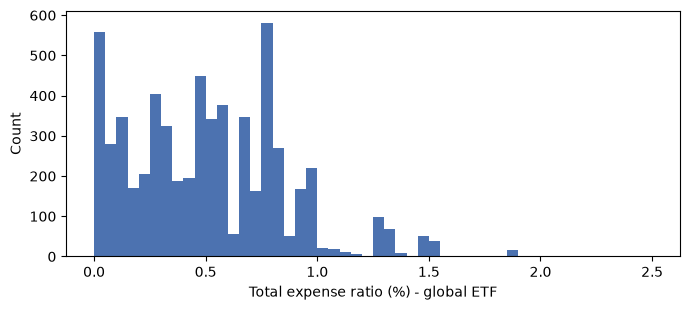

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ch.plot.hist(bins=50, ax=ax, color="#4C72B0")
ax.set_xlabel("Total expense ratio (%) - global ETF")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

> **시사점:** 해외ETF는 **총보수 결측 0%**(중앙값 0.49%, 0% 상품 363건)로, 결측 81.9%인 국내ETF와 커버리지가 정확히 반대다. 반대로 기초지수는 국내가 95% 결측, 해외가 48% 결측이다. 따라서 **"보수가 싼 ETF" 질의는 해외ETF에만 답할 수 있고**, 국내·해외를 한 답변에 섞으면 국내 상품이 부당하게 누락된다. 온톨로지에서 `expenseRatio`는 공통 속성으로 두되, **커버리지 편향을 RAG 응답 정책에 명시**해야 한다.

## 6. 지수복제방식 · 인버스 · 레버리지

In [18]:
pd.DataFrame(
    {
        "cu_index_repl_mthd(지수복제방식)": df.cu_index_repl_mthd.replace("", "(결측)").value_counts(),
        "cu_index_tracking_yn(지수추종)": df.cu_index_tracking_yn.replace("", "(결측)").value_counts(),
        "cu_inverse_short_yn(인버스/숏)": df.cu_inverse_short_yn.replace("", "(결측)").value_counts(),
        "cu_lev_fector(배수)": df.cu_lev_fector.replace("", "(결측)").value_counts(),
    }
)

,cu_index_repl_mthd(지수복제방식),cu_index_tracking_yn(지수추종),cu_inverse_short_yn(인버스/숏),cu_lev_fector(배수)
(결측),3630.0,3630.0,5854.0,5136.0
-0.5,NaN,NaN,NaN,1.0
-1.5,NaN,NaN,NaN,1.0
-2,NaN,NaN,NaN,92.0
-3,NaN,NaN,NaN,34.0
1.2,NaN,NaN,NaN,25.0
1.25,NaN,NaN,NaN,2.0
1.3,NaN,NaN,NaN,2.0
1.5,NaN,NaN,NaN,6.0
2,NaN,NaN,NaN,677.0


In [19]:
# 복제방식 결측 = 지수추종 아님(액티브)인지 확인
print(pd.crosstab(df.cu_index_repl_mthd.replace("", "(결측)"), df.cu_index_tracking_yn.replace("", "(결측)")).to_string())
print("\n복제방식 결측 & 기초지수 sentinel:", int((df.cu_index_repl_mthd == "").sum() and ((df.cu_index_repl_mthd == "") & is_sent).sum()))
print("복제방식 유효 & 기초지수 sentinel:", int(((df.cu_index_repl_mthd != "") & is_sent).sum()))

cu_index_tracking_yn  (결측)     Y
cu_index_repl_mthd              
(결측)                  3630     0
Full                     0   278
Optimized                0  1826
Other                    0     6
Swap                     0   297

복제방식 결측 & 기초지수 sentinel: 2451
복제방식 유효 & 기초지수 sentinel: 480


In [20]:
# ★ 07-11 배포본에서 전량 결측이던 cu_lev_fector에 값이 들어왔다.
print("cu_lev_fector 전량 결측:", (df.cu_lev_fector == "").all(),
      "| 결측률:", round((df.cu_lev_fector == "").mean(), 4))
print(df.cu_lev_fector.replace("", "(결측)").value_counts().to_string())
print()
for pat, lab in [(r"\b2X\b|\bUltra\b", "2X"), (r"\b3X\b", "3X"), (r"Inverse|\bBear\b|\bShort\b", "인버스")]:
    print(f"  상품명 '{lab}' 패턴: {int(df.pd_nm.str.contains(pat, case=False, regex=True).sum())}건")

cu_lev_fector 전량 결측: False | 결측률: 0.8508
cu_lev_fector
(결측)    5136
2        677
-2        92
3         60
-3        34
1.2       25
1.5        6
1.3        2
1.25       2
4          1
-1.5       1
-0.5       1

  상품명 '2X' 패턴: 751건
  상품명 '3X' 패턴: 70건
  상품명 '인버스' 패턴: 281건


In [21]:
# 컬럼값과 상품명 정규식이 서로 일치하는지 — 컬럼을 믿어도 되는지 검증
lev2 = df.cu_lev_fector.isin(["2", "-2"])
nm2 = df.pd_nm.str.contains(r"\b2X\b|\bUltra\b", case=False, regex=True)
print("cu_lev_fector ±2 이면서 상품명에도 2X/Ultra:", int((lev2 & nm2).sum()), "/", int(lev2.sum()))
print("상품명에 2X/Ultra이나 cu_lev_fector 결측     :", int((nm2 & (df.cu_lev_fector == "")).sum()))
print("\ncu_inverse_short_yn='Y' 이면서 상품명에 Inverse/Bear/Short 없는 건:",
      int(((df.cu_inverse_short_yn == "Y") & ~df.pd_nm.str.contains("Inverse|Bear|Short", case=False)).sum()))

cu_lev_fector ±2 이면서 상품명에도 2X/Ultra: 683 / 769
상품명에 2X/Ultra이나 cu_lev_fector 결측     : 67

cu_inverse_short_yn='Y' 이면서 상품명에 Inverse/Bear/Short 없는 건: 5


> **시사점:** `cu_index_repl_mthd`와 `cu_index_tracking_yn`은 **결측 패턴이 완전히 동일**해, 결측분 = "지수를 추종하지 않는 액티브형"으로 읽는 것이 타당하다. 즉 결측 자체가 정보다. **`cu_lev_fector`(배수)는 07-11 배포본에서 전량 결측이었으나 08-24에서 14.9%가 채워졌다** — 레버리지·인버스 상품은 사실상 전부 값이 있으므로 "레버리지 2배 ETF" 질의가 **컬럼 기반으로 답변 가능**해졌다(1배 상품은 여전히 결측이라 "결측=1배"로 읽어야 한다). 상품명 정규식은 이제 교차 검증용이다.

## 7. 자산군 · 투자지역 — 국내와의 체계 불일치

In [22]:
pd.DataFrame(
    {
        "해외ETF wu_inv_ast_type": df.wu_inv_ast_type.replace("", "(결측)").value_counts(),
        "국내ETF wu_inv_ast_type": kr_etf.wu_inv_ast_type.replace("", "(결측)").value_counts(),
    }
)

,해외ETF wu_inv_ast_type,국내ETF wu_inv_ast_type
wu_inv_ast_type,,
(결측),11.0,NaN
Alternatives,2061.0,NaN
Bond,1112.0,NaN
Commodity,111.0,NaN
Equity,2595.0,NaN
Mixed Assets,138.0,NaN
Money Market,9.0,NaN
기타,NaN,19.0
단기자금,NaN,31.0


In [23]:
print("해외 wu_inv_rgn 고유:", df.wu_inv_rgn.nunique(), "/ 국내:", kr_etf.wu_inv_rgn.nunique())
print()
print(df.wu_inv_rgn.replace("", "(결측)").value_counts().head(20).to_string())

해외 wu_inv_rgn 고유: 60 / 국내: 11

wu_inv_rgn
United States of America    4520
Global                       766
Global Ex US                 311
Global Emerging Markets      177
China                         48
Europe                        41
Japan                         25
India                         24
(결측)                          11
Asia Pacific                   9
Brazil                         9
Asia Pacific ex Japan          8
Korea                          8
United Kingdom                 5
Switzerland                    4
Latin America                  4
Israel                         4
Germany                        4
Canada                         4
Australia                      3


In [24]:
# 공통 축 정규화 매핑표 초안
ASSET_MAP = {
    "주식": "Equity", "Equity": "Equity",
    "채권": "Bond", "Bond": "Bond",
    "혼합자산": "MixedAsset", "Mixed Assets": "MixedAsset",
    "단기자금": "MoneyMarket", "Money Market": "MoneyMarket",
    "원자재": "Commodity", "Commodity": "Commodity",
    "통화": "Currency",
    "부동산": "RealEstate",
    "기타": "Alternatives", "Alternatives": "Alternatives",
}
REGION_MAP = {
    "국내": "Domestic", "Korea": "Domestic",
    "미국": "NorthAmerica", "United States of America": "NorthAmerica", "Canada": "NorthAmerica", "남미/북미": "NorthAmerica",
    "글로벌": "Global", "Global": "Global", "Global Ex US": "Global",
    "중국": "AsiaExJapan", "China": "AsiaExJapan", "아시아": "AsiaExJapan", "인도": "AsiaExJapan", "India": "AsiaExJapan",
    "베트남": "AsiaExJapan", "Asia Pacific": "AsiaExJapan", "Asia Pacific ex Japan": "AsiaExJapan",
    "일본": "Japan", "Japan": "Japan",
    "유럽": "Europe", "Europe": "Europe", "United Kingdom": "Europe", "Switzerland": "Europe",
    "이머징/브릭스": "EmergingMarkets", "Global Emerging Markets": "EmergingMarkets", "Brazil": "EmergingMarkets",
}
cov = pd.DataFrame(
    [
        {"축": "assetType", "해외 매핑률": round(df.wu_inv_ast_type.isin(ASSET_MAP).mean(), 4),
         "국내 매핑률": round(kr_etf.wu_inv_ast_type.isin(ASSET_MAP).mean(), 4)},
        {"축": "region", "해외 매핑률": round(df.wu_inv_rgn.isin(REGION_MAP).mean(), 4),
         "국내 매핑률": round(kr_etf.wu_inv_rgn.isin(REGION_MAP).mean(), 4)},
    ]
)
cov

,축,해외 매핑률,국내 매핑률
0,assetType,0.9982,0.8931
1,region,0.9871,1.0000


In [25]:
print("REGION_MAP 미커버 해외 지역값 (상위):")
print(df.loc[~df.wu_inv_rgn.isin(REGION_MAP) & (df.wu_inv_rgn != ""), "wu_inv_rgn"].value_counts().head(15).to_string())

REGION_MAP 미커버 해외 지역값 (상위):
wu_inv_rgn
Latin America    4
Germany          4
Israel           4
Australia        3
Taiwan           3
Mexico           3
Vietnam          3
Indonesia        2
Norway           2
Saudi Arabia     2
North America    2
EuroZone         2
Greater China    2
Italy            1
Philippines      1


> **시사점:** 자산군은 국내가 한글 8종, 해외가 영문 6종인데 **해외에만 있는 `Alternatives` 1,800건(31.9%)** 이 국내 체계에 대응어가 없다(국내는 '기타' 18건뿐). 투자지역은 국내 11종 vs 해외 **60종**으로 입도 차이가 극심하다(해외는 국가 단위, 국내는 권역 단위). 두 테이블을 같은 축으로 질의하려면 위와 같은 **공통 정규화 매핑 계층이 온톨로지에 반드시 있어야 하며**, 매핑 불가 값은 잘라내지 말고 `OtherRegion`으로 보존해야 한다.

## 8. 외부 조인키 커버리지 — 구성종목 취득 가능성

In [26]:
keys = ["pd_isin_cd", "pd_lipper_id", "pd_us_cik", "pd_itm_no", "pd_itm_no_ma"]
pd.DataFrame(
    [
        {
            "키": k,
            "결측률": round((df[k] == "").mean(), 4),
            "유효건수": int((df[k] != "").sum()),
            "고유값수": int(df[k][df[k] != ""].nunique()),
            "유일성": bool(df[k][df[k] != ""].is_unique),
        }
        for k in keys
    ]
)

,키,결측률,유효건수,고유값수,유일성
0,pd_isin_cd,0.0020,6025,5962,False
1,pd_lipper_id,0.0018,6026,5963,False
2,pd_us_cik,0.0030,6019,389,False
3,pd_itm_no,0.0000,6037,6037,True
4,pd_itm_no_ma,0.0000,6037,6037,True


In [27]:
# ISIN 중복 원인 규명
d_isin = df[(df.pd_isin_cd != "") & df.pd_isin_cd.duplicated(keep=False)]
print("ISIN 중복에 걸린 행:", len(d_isin), "/ 중복 ISIN 종류:", d_isin.pd_isin_cd.nunique())
ex = d_isin.pd_isin_cd.value_counts().index[0]
df[df.pd_isin_cd == ex][["pd_itm_no", "pd_nm", "pd_exg_mkt_cd", "pd_isin_cd", "du_clpr", "du_val_1d"]]

ISIN 중복에 걸린 행: 126 / 중복 ISIN 종류: 63


,pd_itm_no,pd_nm,pd_exg_mkt_cd,pd_isin_cd,du_clpr,du_val_1d
9,AFGR.K,First Trust Active Factor Large Cap Growth ETF,AMX,US33740F7895,37.0326,47498
2375,MMLG.K,First Trust Multi-Manager Large Growth ETF,AMX,US33740F7895,37.0326,47498


In [28]:
print("중복 ISIN 쌍의 거래소 조합:")
print(d_isin.groupby("pd_isin_cd").pd_exg_mkt_cd.apply(lambda s: " / ".join(sorted(s))).value_counts().head(8).to_string())
print("\n중복 쌍의 종목코드 접미사 조합:")
print(d_isin.groupby("pd_isin_cd").pd_itm_no.apply(lambda s: " / ".join(sorted(x.split(".")[-1] if "." in x else "(없음)" for x in s))).value_counts().head().to_string())

중복 ISIN 쌍의 거래소 조합:
pd_exg_mkt_cd
AMX / AMX    36
NAS / NAS    15
102 / AMX     5
AMX / NAS     4
NYS / NYS     1
101 / NAS     1
NAS / NYS     1

중복 쌍의 종목코드 접미사 조합:
pd_itm_no
K / K       36
O / O       16
(없음) / K     6
K / O        4
(없음) / O     1


In [29]:
# SEC CIK — 구성종목(N-PORT) 취득 경로
cik = df[df.pd_us_cik != ""]
print("pd_us_cik 유효:", len(cik), "행 / 고유 CIK:", cik.pd_us_cik.nunique())
print("→ 전체 대비 %.1f%%" % (len(cik) / len(df) * 100))
print("\nCIK 보유 상품의 운용사 상위:")
print(cik.cu_fund_mgmt_co.value_counts().head(10).to_string())
print("\nCIK 하나에 묶인 상품 수 분포:")
print(cik.pd_us_cik.value_counts().value_counts().sort_index().head().to_string())

pd_us_cik 유효: 6019 행 / 고유 CIK: 389
→ 전체 대비 99.7%

CIK 보유 상품의 운용사 상위:
cu_fund_mgmt_co
BlackRock Fund Advisors             498
First Trust Advisors LP             327
Tidal Investments LLC               319
Invesco Capital Management LLC      260
Corgi Strategies LLC                197
Innovator Capital Management LLC    187
SSGA Funds Management Inc           176
ProShare Advisors LLC               173
Themes Management Company LLC       149
Rafferty Asset Management LLC       147

CIK 하나에 묶인 상품 수 분포:
count
1    149
2     30
3     19
4     16
5     12


> **시사점:** ISIN은 결측 0.16%로 사실상 완비이나 **50개 ISIN이 2행씩(총 100행) 중복**된다. 중복 쌍의 거래소 조합을 보면 39쌍이 **같은 거래소**(AMX/AMX 26, NAS/NAS 12, NYS/NYS 1)로, 이는 복수 상장이 아니라 **티커 변경 후 구 레코드가 정리되지 않은 중복**이다(예: `EUSM.K`와 `ESUM.K`가 같은 상품·같은 종가·같은 ISIN). 나머지 11쌍만이 실제 교차 거래소 건이다. 따라서 ISIN을 유일키로 쓰면 조인이 2배로 팽창하므로, **온톨로지에서는 `pd_itm_no`(유일성 확인됨)를 인스턴스 ID로 두고 ISIN은 `sameAs` 성격의 외부 식별자 속성**으로 붙여야 한다. `pd_us_cik`은 5,633행에 존재하지만 **고유 CIK는 374개뿐**이라, 하나의 CIK(운용사 트러스트) 아래 수십~수백 개 상품이 묶인다(BlackRock 497행이 소수의 CIK 공유) — SEC EDGAR N-PORT로 구성종목을 받을 때 **CIK만으로는 개별 ETF를 특정할 수 없고 시리즈 ID가 추가로 필요**하다. 이것이 구성종목(holdings) 취득의 실제 병목이다.

## 9. 가격 신선도 · 무거래 상품

In [30]:
print("du_upt_dt 상위:")
print(df.du_upt_dt.value_counts().head(5).to_string())
print("\ndu_clpr_base_dt 상위:")
print(df.du_clpr_base_dt.replace("", "(결측)").value_counts().head(5).to_string())
print("\ndu_base_dt_match_yn:", df.du_base_dt_match_yn.replace("", "(결측)").value_counts().to_dict())

du_upt_dt 상위:
du_upt_dt
20260822    5698
20260610      14
20260729      13
20260411      12
20250913       8

du_clpr_base_dt 상위:
du_clpr_base_dt
20260821    5687
20260609      14
(결측)          14
20260728      13
20260410      12

du_base_dt_match_yn: {'N': 6023, '(결측)': 14}


In [31]:
bd = pd.to_datetime(df.du_clpr_base_dt.where(df.du_clpr_base_dt.str.fullmatch(r"\d{8}")), format="%Y%m%d", errors="coerce")
latest = bd.max()
stale_days = (latest - bd).dt.days
pd.cut(stale_days, [-1, 0, 7, 30, 90, 180, 10000],
       labels=["당일", "1주 이내", "1개월 이내", "3개월 이내", "6개월 이내", "6개월 초과"]).value_counts().sort_index().to_frame("건수")

,건수
du_clpr_base_dt,
당일,5687
1주 이내,14
1개월 이내,32
3개월 이내,57
6개월 이내,80
6개월 초과,153


In [32]:
stale = df[stale_days > 180]
print("종가 6개월 이상 stale:", len(stale), "건 (최고 오래된 기준일:", bd.min(), ")")
stale[["pd_itm_no", "pd_nm", "du_clpr_base_dt", "du_clpr", "du_val_1d", "pd_sale_yn"]].head(10)

종가 6개월 이상 stale: 153 건 (최고 오래된 기준일: 2025-07-28 00:00:00 )


,pd_itm_no,pd_nm,du_clpr_base_dt,du_clpr,du_val_1d,pd_sale_yn
13,AGIH.K,iShares Inflation Hedged US Aggregate Bond ETF,20250818,24.98,225,1
27,ARKA.K,ARK 21Shares Active Bitcoin Futures Strategy ETF,20250925,68.3201,1135503,1
41,AWEG.K,Alger Weatherbie Enduring Growth ETF,20251224,22.55,474,1
79,BSCP.O,Invesco BulletShares 2025 Corporate Bond ETF,20251215,20.675,37916295,1
158,DMCY.K,Democracy International Fund,20260217,32.99,363,1
209,EVAV.K,Direxion Daily Electric & Autonms Vhcls Bl 2X Shs,20251023,28.624,21276,1
376,LFAE.K,LifeX 2048 Longevity Income ETF,20250912,118.9978,357,1
377,LFAJ.K,LifeX 2051 Longevity Income ETF,20250915,133.0212,0,1
378,LFAN.K,LifeX 2054 Longevity Income ETF,20250915,145.857,0,1
407,MOTE.K,VanEck Morningstar ESG Moat ETF,20250919,28.79,115,1


In [33]:
v = num(df.du_val_1d)
print("du_val_1d(일거래대금) = 0 인 상품:", int((v == 0).sum()), "건 (%.1f%%)" % ((v == 0).mean() * 100))
print("du_vol_1d(일거래량) = 0 인 상품:", int((num(df.du_vol_1d) == 0).sum()), "건")
print()
print("무거래 상품의 AUM 분포(백만USD):")
print((num(df.loc[v == 0, "du_last_aum"]) / 1e6).describe().round(2).to_string())

du_val_1d(일거래대금) = 0 인 상품: 91 건 (1.5%)
du_vol_1d(일거래량) = 0 인 상품: 91 건

무거래 상품의 AUM 분포(백만USD):
count     91.00
mean      18.46
std       65.47
min        0.12
25%        0.90
50%        2.93
75%       13.14
max      442.60


> **시사점:** 종가 기준일이 최신(2026-06-16)이 아닌 종목이 존재하며 **2025년 9월 수준까지 뒤처진 stale 종목**이 남아 있다. 더 중요하게 `du_base_dt_match_yn`이 **전 행 'N'** 이라 종가일과 NAV일이 애초에 일치하지 않는다 — 괴리율·수익률 계산의 신뢰 한계다. 일거래대금 0인 무거래 상품도 상당수라, "거래가 활발한 ETF" 질의는 `du_val_1d > 0`과 기준일 신선도를 함께 걸어야 한다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| 한글 컬럼명 | 49개 전부 부여 (상속 36 + 직접해석 13) | `docs/etf_gl_column_names.csv` 산출 |
| 기초지수 실질 결측 | 문장형 sentinel 포함 시 ~48% | ETL에서 sentinel → NULL |
| 총보수 결측 | **0%** (국내는 81.9%) | 보수 질의는 해외만 가능 |
| 거래소코드 오염 | 숫자코드 31건('102' 22 / '101' 9) | 3자 코드만 허용, 나머지 격리 |
| ISIN 중복 | 50개 ISIN × 2행 (39쌍은 동일 거래소=티커변경 잔재) | ISIN은 유일키 불가, pd_itm_no 사용 |
| 고유 CIK | 374개 (5,633행 대비) | N-PORT 조인에 시리즈ID 추가 필요 |
| 투자지역 카디널리티 | 해외 60종 vs 국내 11종 | 공통 정규화 매핑 계층 필수 |